# Climate Data Exploratory Data Analysis

## Introduction
This notebook contains an exploratory data analysis of climate data from 1900 to 2023. The dataset includes global temperatures, CO2 concentration, sea level rise, and Arctic ice area.

Your task is to perform a comprehensive EDA following the requirements in the README.md file.

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot styling
plt.style.use('ggplot')  
sns.set_palette('viridis')
sns.set()
%matplotlib inline

## 1. Data Preparation

Load the climate data and perform necessary cleaning and aggregation.

In [5]:
import pandas as pd
import asyncio
import sys

# Load the dataset
df = pd.read_csv('data/Climate_Change_Indicators.csv') # Place the correct path to the file you are reading here (Make sure to load using the relative path)

# Display the first few rows of the dataset
df.head()

,Year,Global Average Temperature (°C),CO2 Concentration (ppm),Sea Level Rise (mm),Arctic Ice Area (million km²)
0,1948,13.17,397.04,116.25,5.97
1,1996,13.10,313.17,277.92,9.66
2,2015,14.67,311.95,290.32,8.40
3,1966,14.79,304.25,189.71,11.83
4,1992,13.15,354.52,14.84,11.23


In [6]:
# Check for missing values and basic information about the dataset
print("Dataset Information:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())
df.dropna(inplace=True)

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048576 entries, 0 to 1048575
Data columns (total 5 columns):
 #   Column                           Non-Null Count    Dtype  
---  ------                           --------------    -----  
 0   Year                             1048576 non-null  int64  
 1   Global Average Temperature (°C)  1048576 non-null  float64
 2   CO2 Concentration (ppm)          1048576 non-null  float64
 3   Sea Level Rise (mm)              1048576 non-null  float64
 4   Arctic Ice Area (million km²)    1048576 non-null  float64
dtypes: float64(4), int64(1)
memory usage: 40.0 MB
None

Missing Values:
Year                               0
Global Average Temperature (°C)    0
CO2 Concentration (ppm)            0
Sea Level Rise (mm)                0
Arctic Ice Area (million km²)      0
dtype: int64


In [7]:
# Aggregate data by year to create a 124-year time series
yearly_data= df.groupby('Year').agg('mean').reset_index()
pd.set_option('display.float_format', '{:.6f}'.format)
yearly_data.head()

,Year,Global Average Temperature (°C),CO2 Concentration (ppm),Sea Level Rise (mm),Arctic Ice Area (million km²)
0,1900,14.506663,350.373405,150.408288,8.978659
1,1901,14.485343,349.757140,150.548828,8.947272
2,1902,14.476262,349.299686,152.174821,9.035554
3,1903,14.492360,349.644375,150.138338,9.056501
4,1904,14.494241,349.537032,150.667318,8.990691


## 2. Univariate Analysis

Analyze each climate variable independently.

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
# Perform univariate analysis for each climate variable
df.describe()
# Include descriptive statistics and appropriate visualizations



,Year,Global Average Temperature (°C),CO2 Concentration (ppm),Sea Level Rise (mm),Arctic Ice Area (million km²)
count,1048576.000000,1048576.000000,1048576.000000,1048576.000000,1048576.000000
mean,1961.504608,14.499538,350.028018,149.990004,9.000896
std,35.797357,0.866101,40.424093,86.576589,3.462551
min,1900.000000,13.000000,280.000000,0.000000,3.000000
25%,1930.000000,13.750000,314.990000,74.970000,6.000000
50%,1962.000000,14.500000,350.070000,150.020000,9.000000
75%,1993.000000,15.250000,385.020000,224.930000,12.000000
max,2023.000000,16.000000,420.000000,300.000000,15.000000


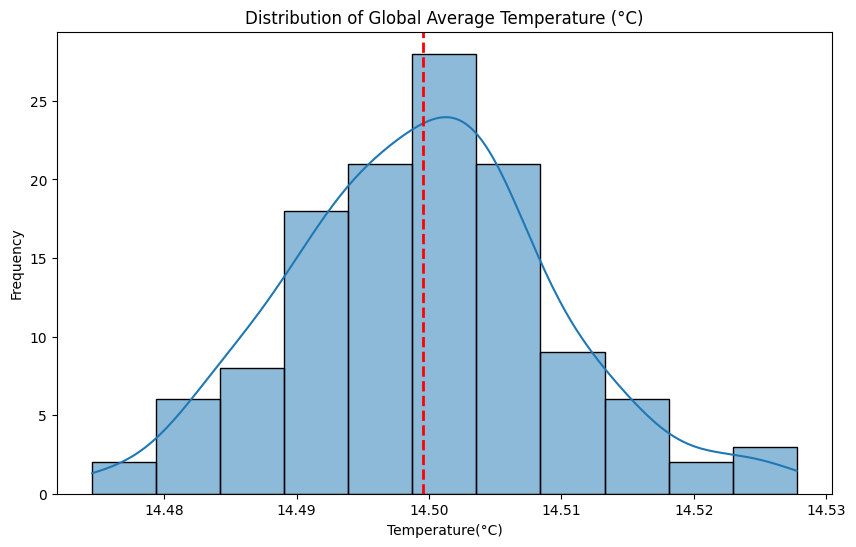

In [34]:
#Histogram of Global Average Temperature
mean_temp = df['Global Average Temperature (°C)'].mean()
plt.figure(figsize=(10,6))
sns.histplot(yearly_data['Global Average Temperature (°C)'], kde= True)
plt.axvline(mean_temp, color='red', linestyle='dashed', linewidth=2, label=f'Mean: {mean_temp:.2f}')
plt.title('Distribution of Global Average Temperature (°C)')
plt.xlabel('Temperature(°C)')
plt.ylabel('Frequency')
plt.show()

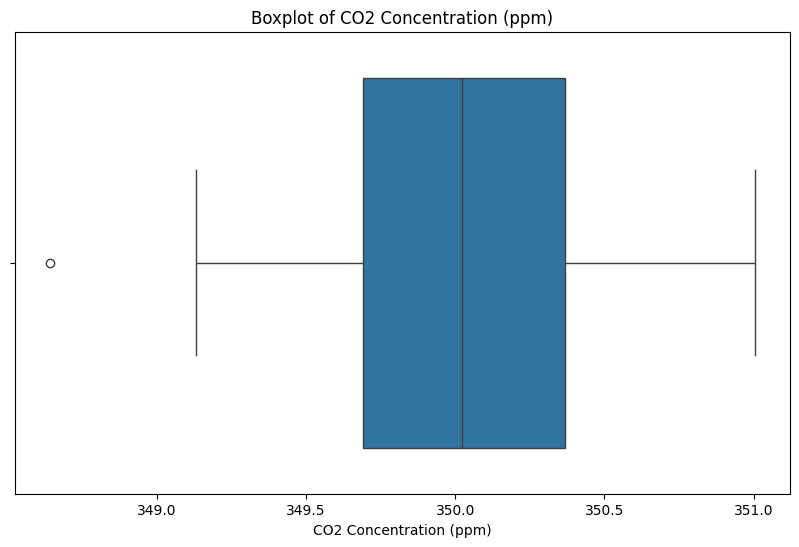

In [33]:
#Boxplot of CO2 Concentration
plt.figure(figsize=(10,6))
sns.boxplot(x=yearly_data['CO2 Concentration (ppm)'])
plt.title('Boxplot of CO2 Concentration (ppm)')
plt.xlabel('CO2 Concentration (ppm)')
plt.show()

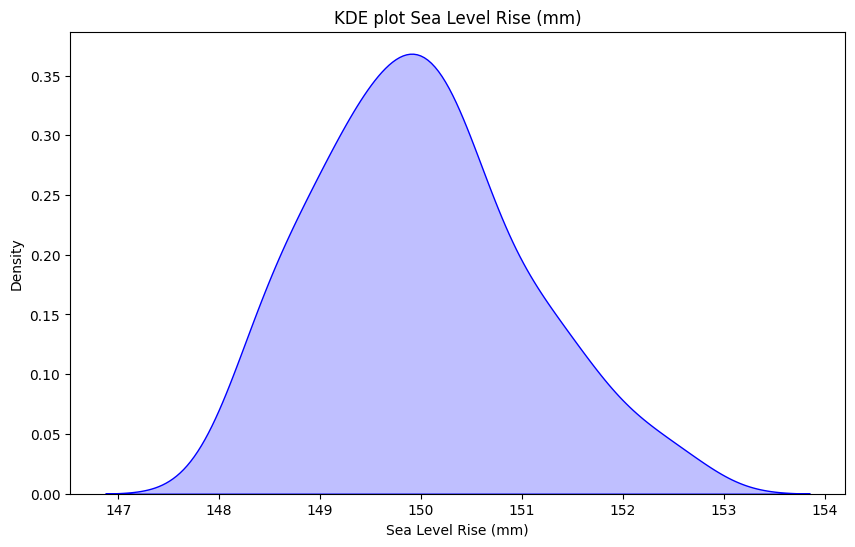

In [32]:
#KDE plot of sea level rise
plt.figure(figsize=(10,6))
sns.kdeplot(yearly_data['Sea Level Rise (mm)'],fill= True, color='blue')
plt.title('KDE plot Sea Level Rise (mm)')
plt.xlabel('Sea Level Rise (mm)')
plt.ylabel('Density')
plt.show()

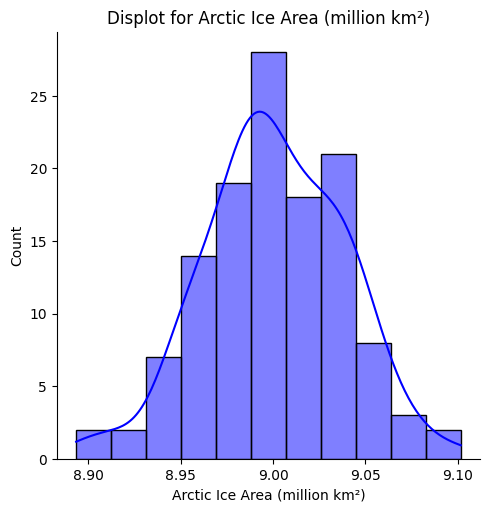

In [31]:
#Displot for arctic ice area
sns.displot(yearly_data['Arctic Ice Area (million km²)'],kde=True,color='blue')
plt.title('Displot for Arctic Ice Area (million km²)')
plt.xlabel('Arctic Ice Area (million km²)')
plt.ylabel('Count')
plt.show()

## 3. Bivariate Analysis

Explore relationships between pairs of climate variables.

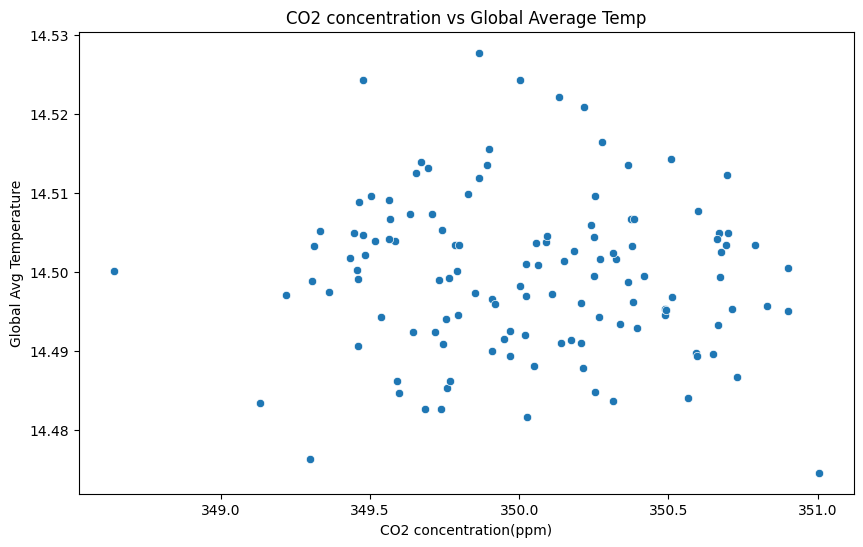

In [30]:
# TODO: Perform bivariate analysis
# Include correlation analysis and appropriate visualizations
# Scatter plot of CO2 concentration vs Global Average Temp
plt.figure(figsize=(10,6))
sns.scatterplot(x=yearly_data['CO2 Concentration (ppm)'],y=yearly_data['Global Average Temperature (°C)'])
plt.title('CO2 concentration vs Global Average Temp')
plt.xlabel('CO2 concentration(ppm)')
plt.ylabel('Global Avg Temperature')
plt.show()




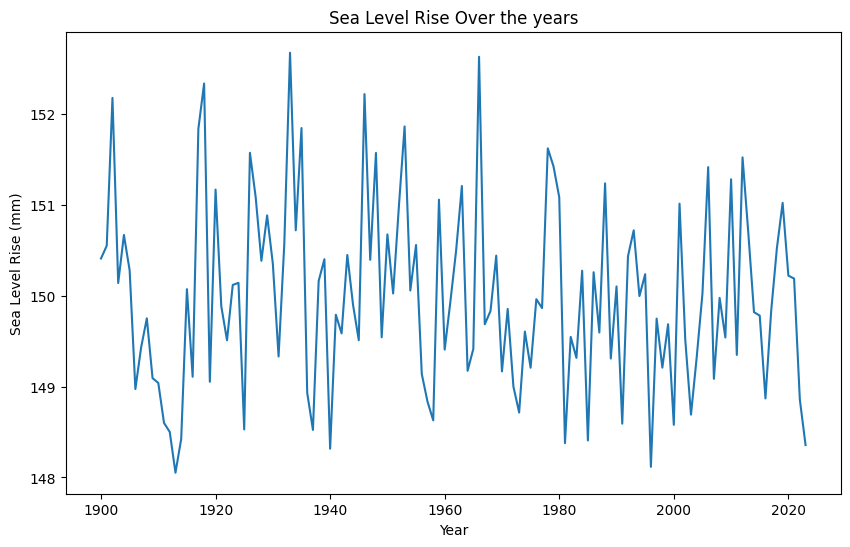

In [29]:
#Line plot of Sea Level rise over the years
plt.figure(figsize=(10,6))
sns.lineplot(x=yearly_data['Year'],y=yearly_data['Sea Level Rise (mm)'])
plt.title('Sea Level Rise Over the years')
plt.xlabel('Year')
plt.ylabel('Sea Level Rise (mm)')
plt.show()
           

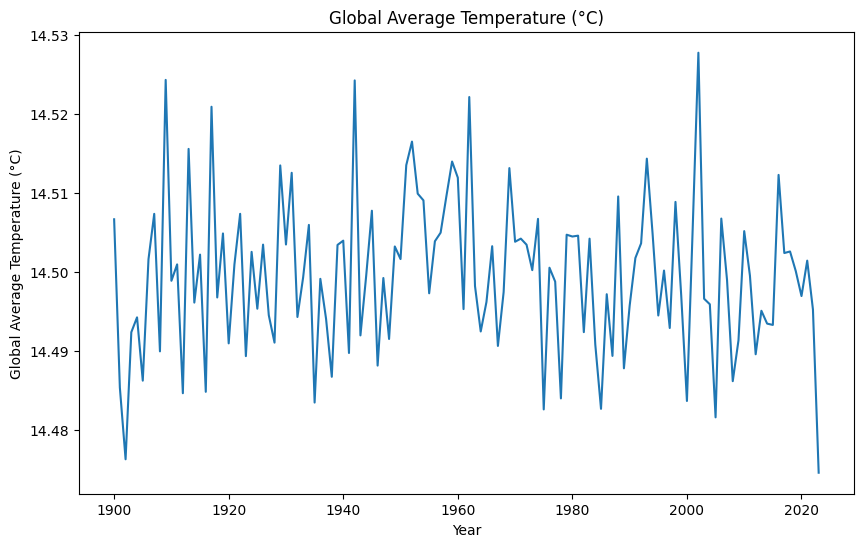

In [28]:
#Global Average Temperature with time plot (°C)
plt.figure(figsize=(10,6))
sns.lineplot(x=yearly_data['Year'],y=yearly_data['Global Average Temperature (°C)'])
plt.title('Global Average Temperature (°C)')
plt.xlabel('Year')
plt.ylabel('Global Average Temperature (°C)')
plt.show()
           

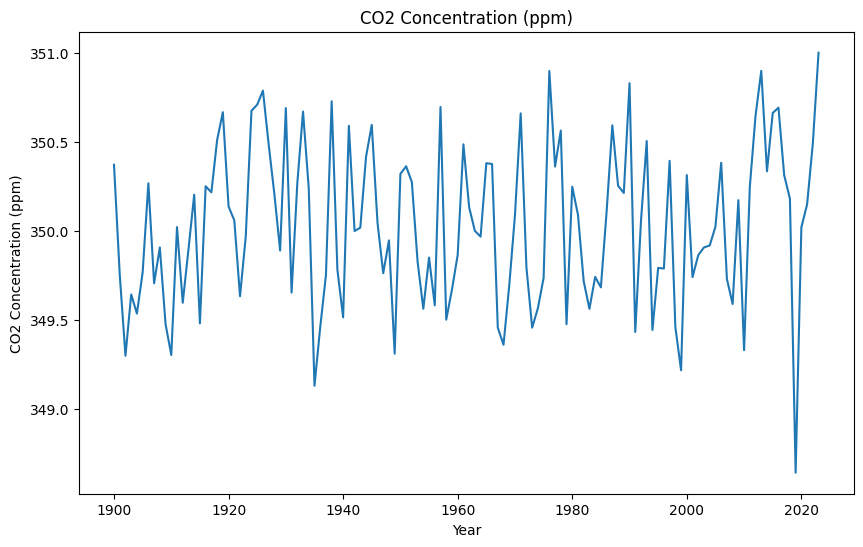

In [27]:
#CO2 Concentration (ppm) with time plot
plt.figure(figsize=(10,6))
sns.lineplot(x=yearly_data['Year'],y=yearly_data['CO2 Concentration (ppm)'])
plt.title('CO2 Concentration (ppm)')
plt.xlabel('Year')
plt.ylabel('CO2 Concentration (ppm)')
plt.show()

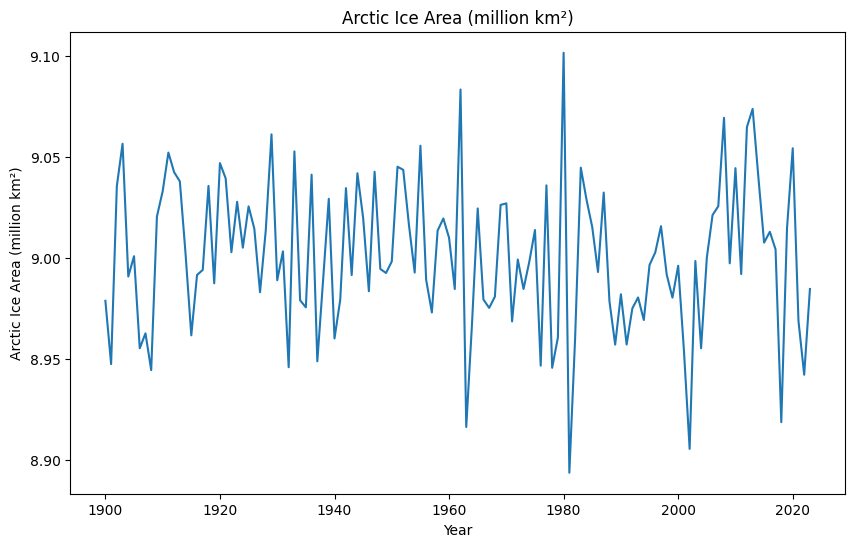

In [26]:
#Arctic Ice Area (million km²) with time plot
plt.figure(figsize=(10,6))
sns.lineplot(x=yearly_data['Year'],y=yearly_data['Arctic Ice Area (million km²)'])
plt.title('Arctic Ice Area (million km²)')
plt.xlabel('Year')
plt.ylabel('Arctic Ice Area (million km²)')
plt.show()

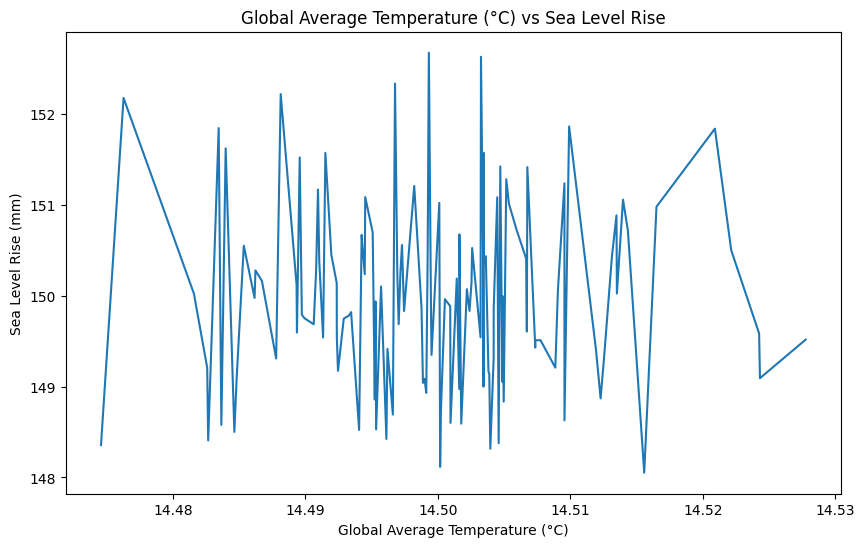

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.pyplot as plt
# plot between global avg temp and sea level rise
df = pd.read_csv('data/Climate_Change_Indicators.csv')
yearly_data= df.groupby('Year').agg('mean').reset_index()
pd.set_option('display.float_format', '{:.6f}'.format)
plt.figure(figsize=(10,6))
sns.lineplot(x=yearly_data['Global Average Temperature (°C)'],y=yearly_data['Sea Level Rise (mm)'])
plt.title('Global Average Temperature (°C) vs Sea Level Rise')
plt.xlabel('Global Average Temperature (°C)')
plt.ylabel('Sea Level Rise (mm)')
plt.show()

<Figure size 700x500 with 0 Axes>

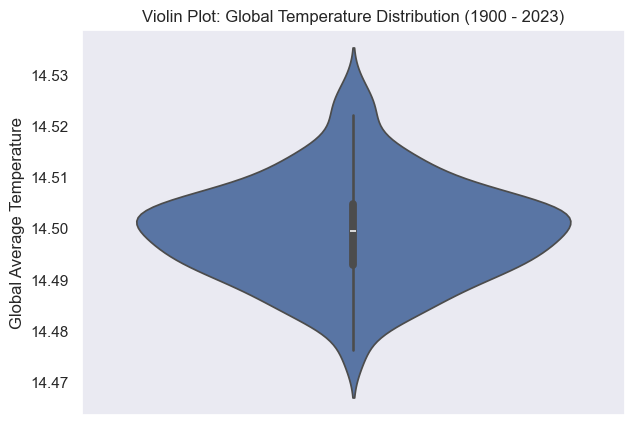

In [8]:
# Violin Plots - Global Temperature over the years
plt.figure(figsize=(7,5))
sns.violinplot(y = yearly_data["Global Average Temperature (°C)"])

# adding features
plt.title("Violin Plot: Global Temperature Distribution (1900 - 2023)")
plt.ylabel("Global Average Temperature")
plt.grid(False)
plt.xticks(rotation=100)
plt.show()

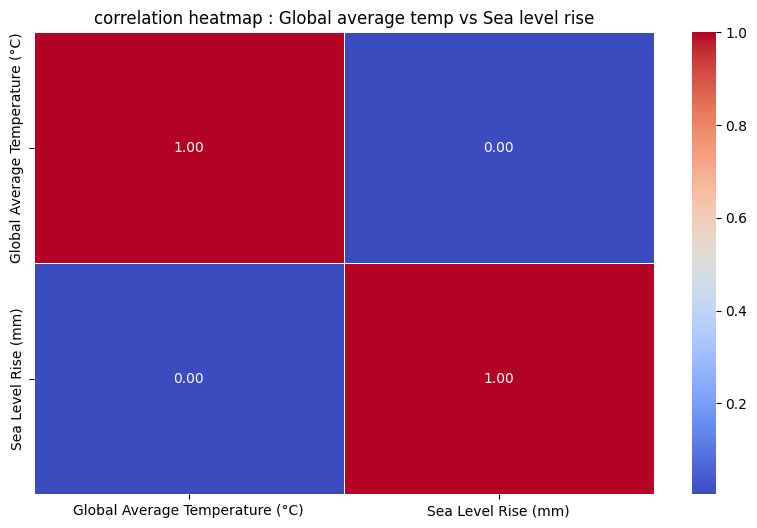

In [36]:
# correlation heat map between Global avg temperature and CO2 Concentration.
yearly_data= df.groupby('Year').agg('mean').reset_index()
pd.set_option('display.float_format', '{:.6f}'.format)
correlation_data =yearly_data[['Global Average Temperature (°C)','CO2 Concentration (ppm)']]
correlation_matrix = correlation_data.corr()
plt.figure(figsize=(10,6))
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm',fmt='.2f',linewidth=0.5)
plt.title('correlation heatmap : Global average temp vs CO2 Concentration (ppm)')
plt.show()

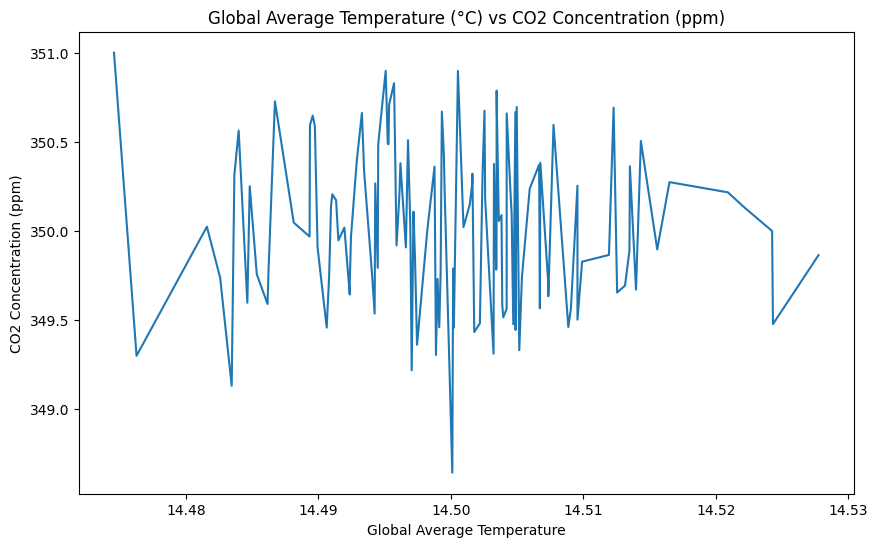

In [37]:
plt.figure(figsize=(10,6))
sns.lineplot(x=yearly_data['Global Average Temperature (°C)'],y=yearly_data['CO2 Concentration (ppm)'])
plt.title('Global Average Temperature (°C) vs CO2 Concentration (ppm)')
plt.xlabel('Global Average Temperature')
plt.ylabel('CO2 Concentration (ppm)')
plt.show()

## 4. Multivariate Analysis

Investigate relationships among three or more variables.

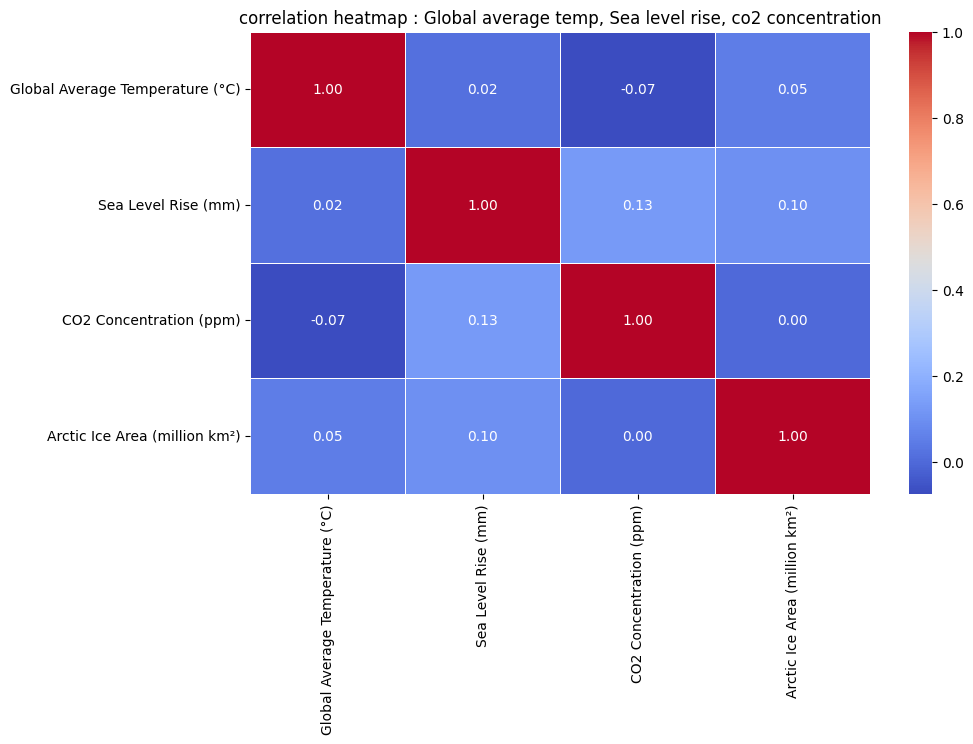

In [23]:
# correlation heat map between Global avg temperature,sea level rise,c02 concentration
correlation_data =yearly_data[['Global Average Temperature (°C)','Sea Level Rise (mm)','CO2 Concentration (ppm)','Arctic Ice Area (million km²)']]
correlation_matrix = correlation_data.corr(method='spearman')
plt.figure(figsize=(10,6))
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm',fmt='.2f',linewidth=0.5)
plt.title('correlation heatmap : Global average temp, Sea level rise, co2 concentration')
plt.show()

<Figure size 1000x600 with 0 Axes>

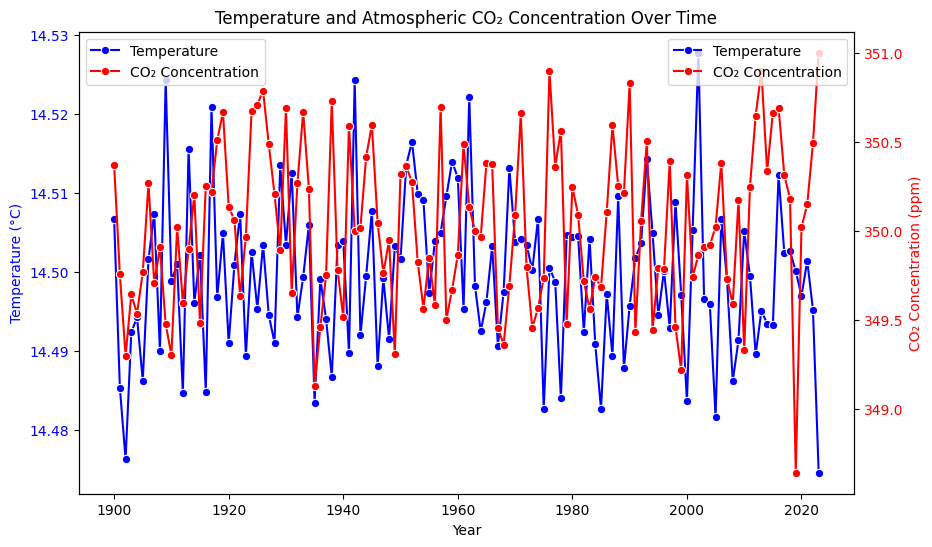

In [15]:
# plotting Temperature and Atmospheric CO₂ Concentration Over Time
plt.figure(figsize=(10, 6))

# Primary Y-axis (Temperature)
fig, ax1 = plt.subplots(figsize=(10, 6))
sns.lineplot(x=yearly_data['Year'], y=yearly_data['Global Average Temperature (°C)'], 
             data=yearly_data, marker='o', label='Temperature', color='blue', ax=ax1)

ax1.set_xlabel('Year')
ax1.set_ylabel('Temperature (°C)', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Secondary Y-axis (CO2 Concentration)
ax2 = ax1.twinx()
sns.lineplot(x=yearly_data['Year'], y=yearly_data['CO2 Concentration (ppm)'], 
             data=yearly_data, marker='o', label='CO₂ Concentration', color='red', ax=ax2)

ax2.set_ylabel('CO₂ Concentration (ppm)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.title('Temperature and Atmospheric CO₂ Concentration Over Time')
plt.show()


                            OLS Regression Results                            
Dep. Variable:                   Year   R-squared:                       0.020
Model:                            OLS   Adj. R-squared:                 -0.004
Method:                 Least Squares   F-statistic:                    0.8224
Date:                Fri, 21 Feb 2025   Prob (F-statistic):              0.484
Time:                        14:54:35   Log-Likelihood:                -618.33
No. Observations:                 124   AIC:                             1245.
Df Residuals:                     120   BIC:                             1256.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const         

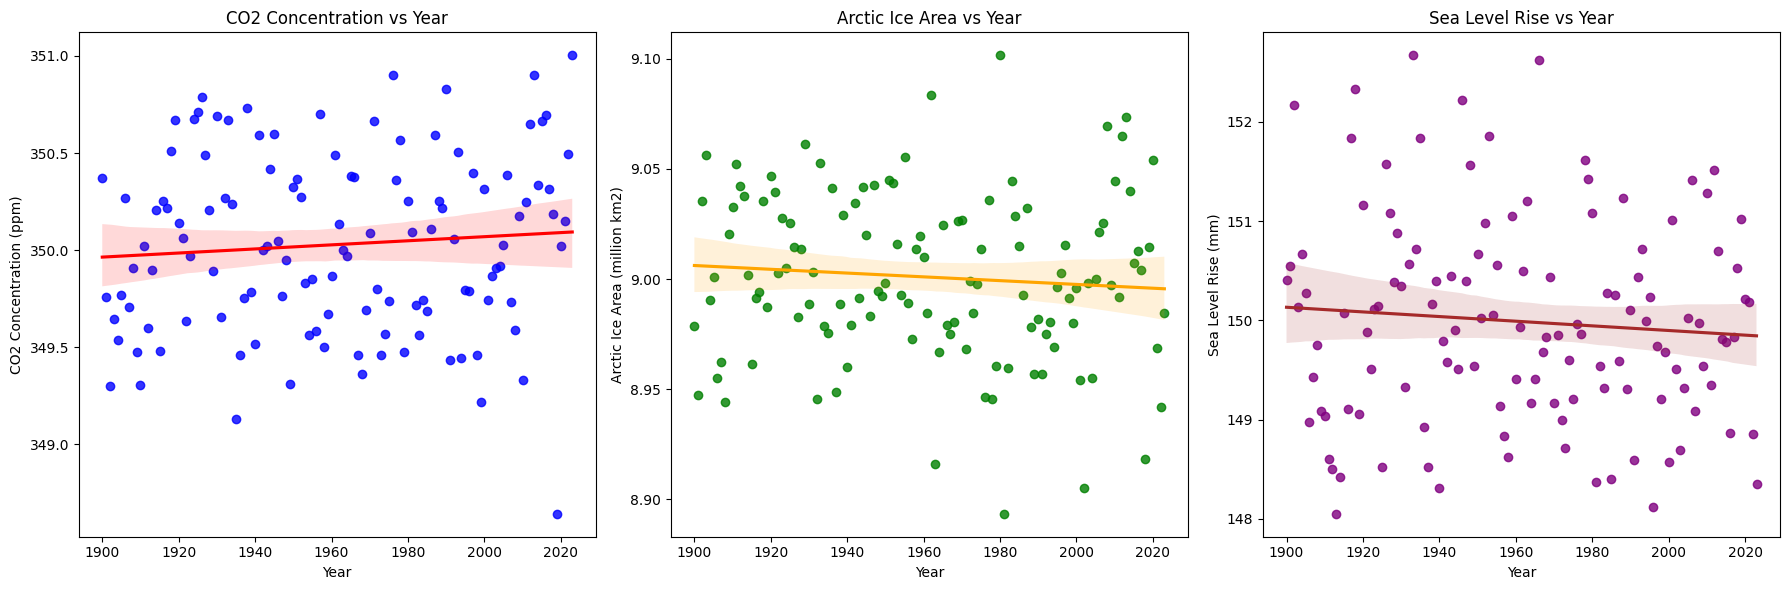

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
yearly_data= df.groupby('Year').agg('mean').reset_index()
pd.set_option('display.float_format', '{:.6f}'.format)

# Perform Multiple Linear Regression
X = yearly_data[['CO2 Concentration (ppm)', 'Arctic Ice Area (million km²)', 'Sea Level Rise (mm)']]
y = yearly_data['Year']
X = sm.add_constant(X)  # Add constant term for intercept
model = sm.OLS(y, X).fit()
print(model.summary())

# Set up the figure and axes
plt.figure(figsize=(18, 6))

# Regression plot: CO2 Concentration vs Year
plt.subplot(1, 3, 1)
sns.regplot(x='Year', y='CO2 Concentration (ppm)', data=yearly_data, scatter_kws={'color': 'blue'}, line_kws={'color': 'red'})
plt.title('CO2 Concentration vs Year')
plt.xlabel('Year')
plt.ylabel('CO2 Concentration (ppm)')

# Regression plot: Arctic Ice Area vs Year
plt.subplot(1, 3, 2)
sns.regplot(x='Year', y='Arctic Ice Area (million km²)', data=yearly_data, scatter_kws={'color': 'green'}, line_kws={'color': 'orange'})
plt.title('Arctic Ice Area vs Year')
plt.xlabel('Year')
plt.ylabel('Arctic Ice Area (million km2)')

# Regression plot: Sea Level Rise vs Year
plt.subplot(1, 3, 3)
sns.regplot(x='Year', y='Sea Level Rise (mm)', data=yearly_data, scatter_kws={'color': 'purple'}, line_kws={'color': 'brown'})
plt.title('Sea Level Rise vs Year')
plt.xlabel('Year')
plt.ylabel('Sea Level Rise (mm)')

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

Text(0, 0.5, 'Arctic Ice Area (million km²)')

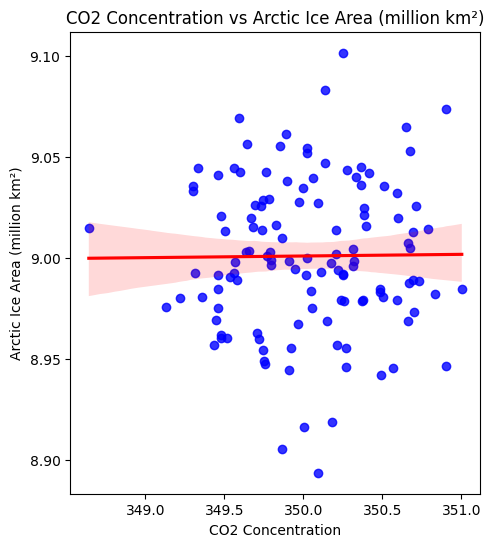

In [23]:
# Regression plot: CO2 Concentration vs Arctic Ice area
plt.figure(figsize=(18,6))
plt.subplot(1, 3, 1)
sns.regplot(x='CO2 Concentration (ppm)', y='Arctic Ice Area (million km²)', data=yearly_data, scatter_kws={'color': 'blue'}, line_kws={'color': 'red'})
plt.title('CO2 Concentration vs Arctic Ice Area (million km²)')
plt.xlabel('CO2 Concentration')
plt.ylabel('Arctic Ice Area (million km²)')

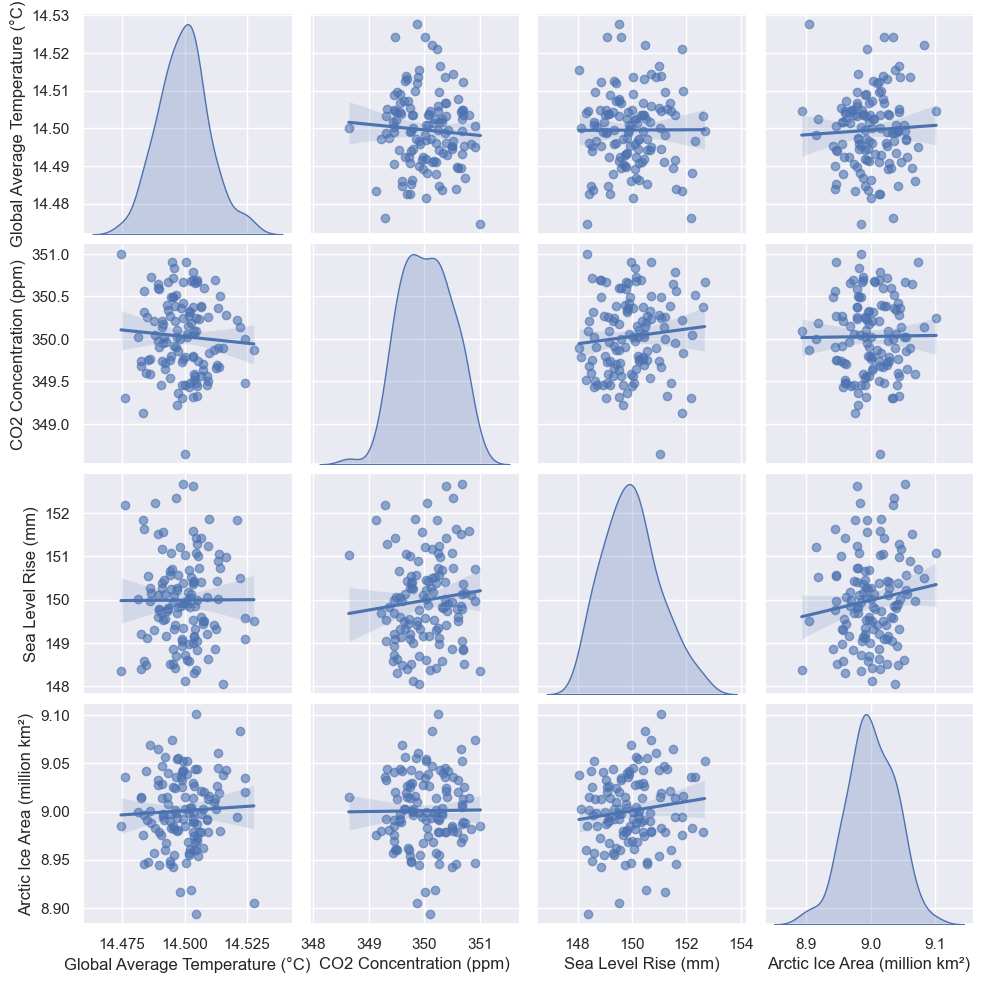

In [11]:
# Pair Plot
df_mv = yearly_data.drop(columns=['Year'])
df_mv
sns.pairplot(df_mv, kind="reg", diag_kind="kde", markers="o", plot_kws={'scatter_kws': {'alpha': 0.6}})
plt.show()

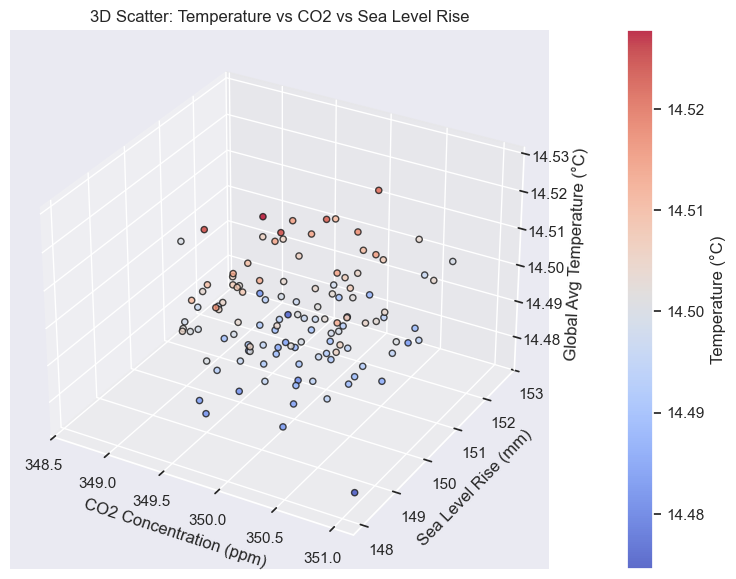

In [12]:
# 3D Scatter Plot // copied from stack overflow
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(yearly_data["CO2 Concentration (ppm)"], yearly_data["Sea Level Rise (mm)"], yearly_data["Global Average Temperature (°C)"], c=yearly_data["Global Average Temperature (°C)"], cmap="coolwarm", edgecolor="k", alpha=0.8)

# Labels and title of 3d Plots
ax.set_xlabel("CO2 Concentration (ppm)")
ax.set_ylabel("Sea Level Rise (mm)")
ax.set_zlabel("Global Avg Temperature (°C)")
ax.set_title("3D Scatter: Temperature vs CO2 vs Sea Level Rise")

# For referencing wising different colors
cbar = plt.colorbar(sc, ax=ax, pad=0.1)
cbar.set_label("Temperature (°C)")
plt.show()

## 5. Conclusions and Insights

Summarize your findings and discuss their implications.

Conclusion : These variables inhancing global warming effect on earth the major one is CO2 concentration increasing along with increase in global average temperature.
Finding : The correlation between the different variables are positively correlated. The change in global average temperature and rise in sea level, arctic ice area are positively correlated.
Summary: These variables inhancing global warming effect on earth the major one is CO2 concentration increasing along with increase in global average temperature.
Insight: In this trend it is analysed with different techniques. There is changing in variables(global average temperature, sea level rise, co2 concentration and arctic area) over the year. These variables are changing eaxch other with respect to the increase in year.
Observation : The trend of global average temperature, sea level rise, co2 concentration and arctic area over the year that is 1900 to 2023 observed.
